In [1]:
MODEL_CLS = "aml"
DATASET = "movielens"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{DATASET}/{MODEL_CLS}_{STRATEGY}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\09_RS-DACR


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
from recsys import config, pipeline, trainer, evaluator, utils
import dacr

In [6]:
kwargs = dict(
    path=PATH_CONFIG_FILE,
)

cfg = config.builder.config_builder(**kwargs)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/{cfg.dataset}.csv"
df = pd.read_csv(PATH)

In [9]:
kwargs = dict(
    df=df,
    schema=cfg.schema,
    percentaile=0.9,
)

utils.description.main(**kwargs)

number of user: 609
number of item: 8452
total interaction: 81763
interaction density: 1.5885 %
max interaction of user: 2117
max interaction of item: 315
top 10.0 % interaction of user: 344.4
top 10.0 % interaction of item: 25.0
mean interaction of user: 134
mean interaction of item: 9


In [10]:
kwargs = dict(
    df=df,
    cfg=cfg.pipeline,
)

dataloaders, interactions, histories = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    interactions=interactions,
    num_users=cfg.model.num_users,
    num_items=cfg.model.num_items,
    **cfg.model.params,
)

model = dacr.aml.Module(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.5065
	BEST EPOCH: 32


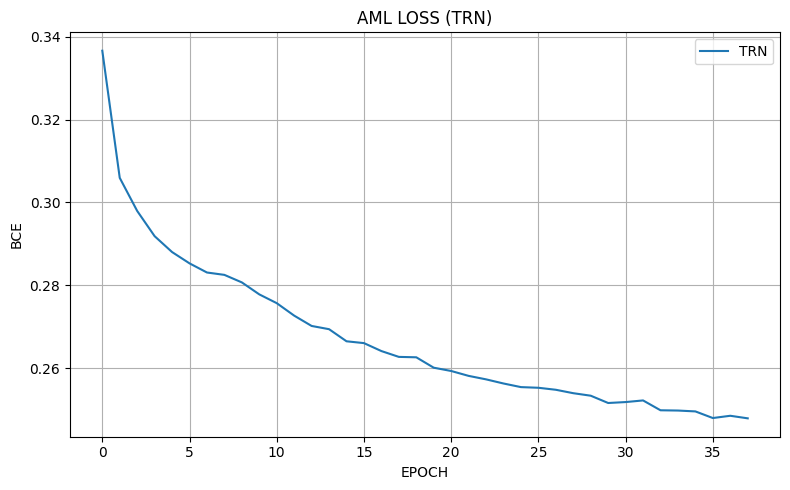

In [14]:
kwargs = dict(
    record=records["trn"],
    label="TRN",
    criterion="BCE",
    title="AML LOSS (TRN)",
)

utils.visualizer.main(**kwargs)

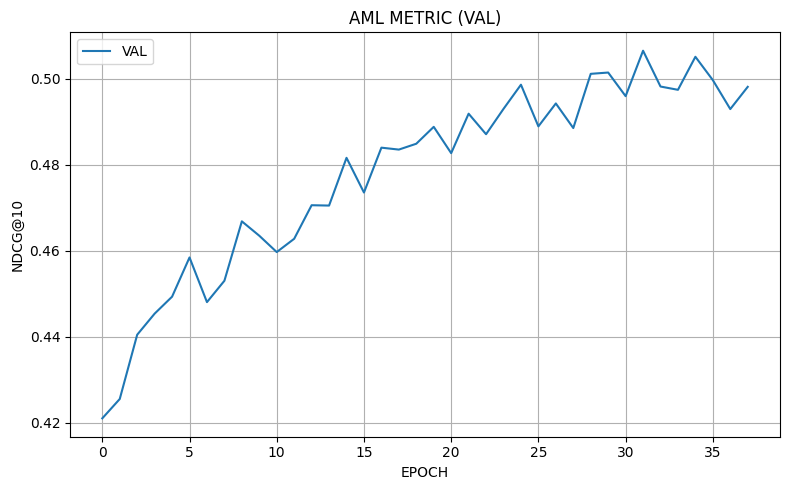

In [15]:
kwargs = dict(
    record=records["val"],
    label="VAL",
    criterion="NDCG@10",
    title="AML METRIC (VAL)",
)

utils.visualizer.main(**kwargs)

# Test

In [16]:
kwargs = dict(
    model=model,
    cfg=cfg.evaluator,
)

evaluator = evaluator.builder.evaluator_builder(**kwargs)

In [17]:
result, metrics_sheet = evaluator(dataloaders["tst"])

TST: 100%|██████████| 3195/3195 [00:05<00:00, 591.03it/s]


In [18]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.875000,0.393421,0.337210,0.244099,0.479557
1,10,0.962171,0.309868,0.480191,0.299886,0.501450
2,15,0.973684,0.256579,0.553647,0.323243,0.516343
3,20,0.980263,0.220312,0.606575,0.336091,0.527863
4,25,0.985197,0.192368,0.638743,0.343794,0.534797
5,50,0.996711,0.126217,0.748715,0.364120,0.567103


# Save

In [19]:
PATH = f'./checkpoints/{cfg.dataset}/{cfg.model_cls}_{cfg.strategy}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)